In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from os.path import join

Init Plugin
Init Graph Optimizer
Init Kernel


In [2]:
path = '/Users/erinbjorkeli/Documents/GitHub/deep-spectra'

In [36]:
data_path = '/Users/erinbjorkeli/phd/Data_Spectra /ReIm_data_2'
N = None

# Internal validation (subset)
val_time   = np.load(join(data_path, 'validate/validate_time_data.npy'), allow_pickle=True)[:N]
val_labels = np.load(join(data_path, 'validate/validate_labels.npy'), allow_pickle=True)[:N]

# External validation (new set)
test_time   = np.load(join(data_path, 'test/test_time_data.npy'), allow_pickle=True)[:N]
test_labels = np.load(join(data_path, 'test/test_labels.npy'), allow_pickle=True)[:N]

In [37]:
train_time = np.load(join(data_path, 'train/train_time_data.npy'), allow_pickle=True)[:N]

In [38]:
train_time.shape

(18357, 1024, 2)

In [32]:
val_time.shape

(2039, 1024, 2)

In [34]:
test_time.shape

(10349, 1024, 2)

# Automap performance

In [4]:
losses_1 = np.load(join(path, 'Automap_class_loss.npy'), allow_pickle=True)

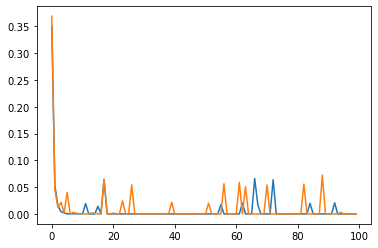

In [5]:
plt.plot(losses_1.T)

In [6]:
mod_path = join(path, 'Automap_classifier_2022-03-13')
model_1 = tf.keras.models.load_model(mod_path)
model_1.summary()

Metal device set to: Apple M1


2022-03-13 22:13:28.495076: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-03-13 22:13:28.495291: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 1024, 2)]         0         
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 1024)              2098176   
_________________________________________________________________
dense_1 (Dense)              (None, 1024)              1049600   
_________________________________________________________________
dense_2 (Dense)              (None, 1024)              1049600   
_________________________________________________________________
reshape (Reshape)            (None, 1024, 1)           0         
_________________________________________________________________
conv1d (Conv1D)              (None, 1024, 128)         768   

In [10]:
pred_1 = model_1.predict(val_time)

In [11]:
target = val_labels[:,0].astype('float32')

In [15]:
pred_1 = model_1.predict(test_time)

In [16]:
target = test_labels[:,0].astype('float32')

### Accuracy

In [17]:
m = tf.keras.metrics.Accuracy()

In [18]:
m(target, pred_1).numpy()

0.020485071

### Sensitivity & specificity

In [21]:
np.sum(pred_1>0.5)

2656

In [22]:
len(pred_1)

10349

In [29]:
p = (pred_1 > 0.5)*1
p

array([[0],
       [0],
       [0],
       ...,
       [1],
       [1],
       [1]])

Predicted GBM 26.397421399410568% 
 Actual GBM 100.0 %


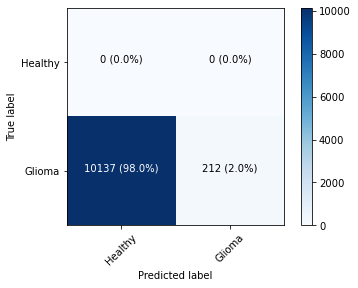

In [23]:
import itertools

cm = tf.math.confusion_matrix(target, pred_1)
cm_norm = cm / len(pred_1)
threshold = int(len(pred_1) * 0.5)
#true negative #false positive
#false negative #true positive
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
tick_marks = np.arange(2)
classes = ['Healthy', 'Glioma']
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Plot the text on each cell 
for i , j in itertools.product(range(2) , range(2)):
    plt.text(j , i , f'{cm[i , j]} ({cm_norm[i , j]*100:.1f}%)', horizontalalignment = 'center', 
             color = 'white' if cm[i , j] > threshold else 'black')

print('Predicted GBM {}% \n Actual GBM {} %'.format(np.sum(pred_1)/len(pred_1)*100, np.sum(target)/len(pred_1)*100))

In [82]:
# Values for Glioma
sens = (212) / (10137 + 212)
spes = (1216) / (1216 + 0)

print('Sensitivity {} and spesificity {}'.format(sens, spes))

Sensitivity 0.02048507102135472 and spesificity 1.0


# Adverserial autoencoding performance

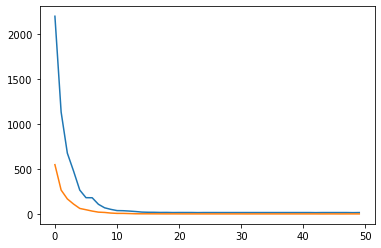

In [40]:
losses_1 = np.load(join(path, 'Autoencode_class_loss.npy'), allow_pickle=True)
plt.plot(losses_1.T)

In [1]:
from Models.Autoencoder_v1 import Autoencoder, Encoder, Decoder

Init Plugin
Init Graph Optimizer
Init Kernel


In [2]:
from Models.Autoencoder_v1 import*

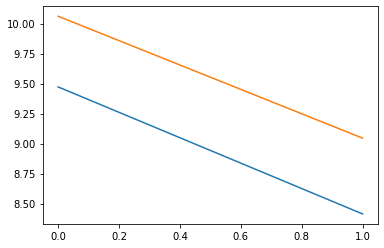

In [5]:
losses_2 = np.load(join(path, 'Autoencode_class_loss.npy'), allow_pickle=True)
plt.plot(losses_2.T)

In [12]:
mod_path = join(path, 'Autoencode_classifier_2022-03-13')
mod_name = 'Autoencode_classifier_2022-03-13.h5'

In [13]:
model_2 = tf.keras.models.load_model(mod_name, custom_objects={'CustomLayer': Autoencoder,
                                                              'CustomLayer': Encoder,
                                                              'CustomLayer': Decoder})
model_2.summary()

ValueError: Unknown layer: Autoencoder. Please ensure this object is passed to the `custom_objects` argument. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

In [3]:
model_2 = autoencodeclass(input_shape=[1024,2])

Metal device set to: Apple M1
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 1024, 2)]    0                                            
__________________________________________________________________________________________________
autoencoder_1 (Autoencoder)     (None, 1024, 1)      16712897    input_1[0][0]                    
__________________________________________________________________________________________________
flatten (Flatten)               (None, 1024)         0           autoencoder_1[0][0]              
__________________________________________________________________________________________________
dense_1 (Dense)                 (None, 1024)         1049600     flatten[0][0]                    
________________________________________________________________

2022-03-13 21:38:53.140695: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-03-13 21:38:53.140812: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [11]:
model_2.load_weights("saved_weights.h5")

In [12]:
model_2.predict(val_time)

ValueError: in user code:

    /Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/tensorflow/python/keras/engine/training.py:1569 predict_function  *
        return step_function(self, iterator)
    /Users/erinbjorkeli/Documents/GitHub/deep-spectra/Models/Autoencoder_v1.py:49 call  *
        encoded = self.encode(input)
    /Users/erinbjorkeli/Documents/GitHub/deep-spectra/Models/Autoencoder_v1.py:16 call  *
        x = Conv1D(filters=f, kernel_size=3, strides=2, activation='relu')(x)
    /Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/tensorflow/python/keras/engine/base_layer.py:1023 __call__  **
        self._maybe_build(inputs)
    /Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/tensorflow/python/keras/engine/base_layer.py:2625 _maybe_build
        self.build(input_shapes)  # pylint:disable=not-callable
    /Users/erinbjorkeli/miniforge3/envs/tf_env/lib/python3.8/site-packages/tensorflow/python/keras/layers/convolutio

### Accuracy

### Sensitivity & specificity

In [15]:
from DataGenerator import FFT_data_generator as gn

In [43]:
data = gn.ValGenerator(N=None, use_labels=[0,1,2])

In [44]:
data.labels.shape

(2039, 3)

In [45]:
data.labels

array([[1, 0, 1],
       [1, 0, 1],
       [0, 5, 3],
       ...,
       [0, 5, 3],
       [0, 5, 3],
       [1, 0, 1]], dtype=object)